In [11]:
import os
import random
import time
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import scipy.io as sio

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [12]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
NUM_WORKERS = 2
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [13]:
DATA_ROOT = "/kaggle/input/datasets/renancostaalencar/compcars"
IMG_ROOT = os.path.join(DATA_ROOT, "image")
MISC_ROOT = os.path.join(DATA_ROOT, "misc")
SPLIT_ROOT = os.path.join(DATA_ROOT, "train_test_split", "classification")

TRAIN_SPLIT_FILE = os.path.join(SPLIT_ROOT, "train.txt")
TEST_SPLIT_FILE = os.path.join(SPLIT_ROOT, "test.txt")
CLASS_NAMES_MAT = os.path.join(MISC_ROOT, "make_model_name.mat")

print("DATA_ROOT:", DATA_ROOT)
print("IMG_ROOT:", IMG_ROOT)
print("SPLIT_ROOT:", SPLIT_ROOT)
print("TRAIN_SPLIT_FILE:", TRAIN_SPLIT_FILE)
print("TEST_SPLIT_FILE:", TEST_SPLIT_FILE)

DATA_ROOT: /kaggle/input/datasets/renancostaalencar/compcars
IMG_ROOT: /kaggle/input/datasets/renancostaalencar/compcars/image
SPLIT_ROOT: /kaggle/input/datasets/renancostaalencar/compcars/train_test_split/classification
TRAIN_SPLIT_FILE: /kaggle/input/datasets/renancostaalencar/compcars/train_test_split/classification/train.txt
TEST_SPLIT_FILE: /kaggle/input/datasets/renancostaalencar/compcars/train_test_split/classification/test.txt


In [14]:
def to_str(x):
    """Convert MATLAB-loaded strings/arrays to clean Python strings."""
    while isinstance(x, np.ndarray):
        if x.size == 0:
            return ""
        if x.size == 1:
            x = x.item()
        else:
            x = x[0]
    if isinstance(x, bytes):
        return x.decode("utf-8", errors="ignore")
    return str(x).strip()

def get_field(obj, *names, default=None):
    """Try multiple possible field names."""
    for name in names:
        if hasattr(obj, name):
            return getattr(obj, name)
    if default is not None:
        return default
    raise AttributeError(f"None of these fields exist: {names}")

In [15]:
def load_class_names(mat_path):
    """
    Load class names from CompCars make_model_name.mat.
    The structure can vary a bit depending on the dataset copy, so this is robust.
    """
    mat = sio.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    # Try common keys
    possible_keys = ["class_names", "make_model_name", "names", "models", "model_names"]
    key = None
    for k in possible_keys:
        if k in mat:
            key = k
            break

    if key is None:
        raise KeyError(f"Could not find class names in {mat_path}. Keys found: {list(mat.keys())}")

    raw = np.atleast_1d(mat[key])
    names = [to_str(x) for x in raw]
    return names

def resolve_image_path(rel_path):
    rel_path = str(rel_path).replace("\\", "/").lstrip("/")

    candidates = [
        os.path.join(DATA_ROOT, rel_path),
        os.path.join(IMG_ROOT, rel_path),
        os.path.join(DATA_ROOT, "image", rel_path),
    ]

    for c in candidates:
        if os.path.exists(c):
            return c

    return candidates[0]

def extract_class_from_path(path_str):
    """
    Try to infer class id from CompCars path.
    Example:
      image/1/1101/2011/xxx.jpg -> class folder is 1101
    """
    parts = Path(path_str).parts

    # Look for the first 4-digit year, then take the folder before it as class
    for i, p in enumerate(parts):
        if len(p) == 4 and p.isdigit():
            if i - 1 >= 0 and parts[i - 1].isdigit():
                return int(parts[i - 1])

    # Fallback: look for a numeric folder near the end
    for p in reversed(parts):
        if p.isdigit():
            return int(p)

    return None

def parse_split_file(split_path):
    rows = []

    with open(split_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # Split on any whitespace or comma
            parts = re.split(r"[,\s]+", line)

            # If the last token is a digit, treat it as label
            label = None
            rel_path = parts[0]

            if len(parts) >= 2:
                maybe_label = parts[-1]
                if maybe_label.isdigit():
                    label = int(maybe_label)
                    rel_path = " ".join(parts[:-1])
                else:
                    rel_path = " ".join(parts)

            rel_path = rel_path.strip()
            img_path = resolve_image_path(rel_path)

            # If label not in txt, try to infer from path structure
            if label is None:
                label = extract_class_from_path(rel_path)

            rows.append({
                "rel_path": rel_path,
                "img_path": img_path,
                "label": label,
                "year": extract_year_from_path(rel_path),
            })

    df = pd.DataFrame(rows)

    # Remove rows where label still couldn't be determined
    df = df[df["label"].notna()].copy()
    df["label"] = df["label"].astype(int)

    return df

def extract_year_from_path(path_str):
    parts = Path(path_str).parts
    for p in reversed(parts):
        if len(p) == 4 and p.isdigit():
            return p
    return ""

In [16]:
class_names = load_class_names(CLASS_NAMES_MAT)
train_df = parse_split_file(TRAIN_SPLIT_FILE)
test_df = parse_split_file(TEST_SPLIT_FILE)

print(train_df["label"].head())
print(train_df["label"].value_counts().head())
print("Unique labels:", train_df["label"].nunique())

0    1
1    1
2    1
3    1
4    1
Name: label, dtype: int64
label
39     620
111    587
157    498
140    469
162    460
Name: count, dtype: int64
Unique labels: 258


In [17]:
# Normalize labels if they are 1-based in the txt files
all_labels = pd.concat(
    [train_df["label"], test_df["label"]],
    ignore_index=True
).dropna()

if len(all_labels) > 0:
    min_label = int(all_labels.min())
    max_label = int(all_labels.max())

    # If labels are 1-based and match class count, shift to 0-based
    if min_label == 1 and max_label == len(class_names):
        train_df["label"] = train_df["label"].apply(lambda x: x - 1 if pd.notna(x) else x)
        test_df["label"] = test_df["label"].apply(lambda x: x - 1 if pd.notna(x) else x)
        print("Converted labels from 1-based to 0-based indexing.")

print("Classes:", len(class_names))
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print(train_df.head())
print(test_df.head())

Classes: 2004
Train columns: ['rel_path', 'img_path', 'label', 'year']
Test columns: ['rel_path', 'img_path', 'label', 'year']
                       rel_path  \
0  78/1/2010/439374a1456969.jpg   
1  78/1/2010/6c5730eb35dbfc.jpg   
2  78/1/2014/a2b9bfe21409f4.jpg   
3  78/1/2013/043602fa21a621.jpg   
4  78/1/2012/ccc640bfa095e3.jpg   

                                            img_path  label  year  
0  /kaggle/input/datasets/renancostaalencar/compc...      1  2010  
1  /kaggle/input/datasets/renancostaalencar/compc...      1  2010  
2  /kaggle/input/datasets/renancostaalencar/compc...      1  2014  
3  /kaggle/input/datasets/renancostaalencar/compc...      1  2013  
4  /kaggle/input/datasets/renancostaalencar/compc...      1  2012  
                       rel_path  \
0  78/1/2014/3ac218c0c6c378.jpg   
1  78/1/2010/588feea1fcc809.jpg   
2  78/1/2010/071c428717ceca.jpg   
3  78/1/2010/4c119af3fdb787.jpg   
4  78/1/2014/1453dbb876c191.jpg   

                                           

In [18]:
class CompCarsDataset(Dataset):
    def __init__(self, df, transform=None, return_label=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_label = return_label and ("label" in self.df.columns) and self.df["label"].notna().all()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.return_label:
            label = int(row["label"])
            return image, label
        else:
            return image

In [19]:
print(train_df.head(10)[["rel_path", "label", "year"]])

                       rel_path  label  year
0  78/1/2010/439374a1456969.jpg      1  2010
1  78/1/2010/6c5730eb35dbfc.jpg      1  2010
2  78/1/2014/a2b9bfe21409f4.jpg      1  2014
3  78/1/2013/043602fa21a621.jpg      1  2013
4  78/1/2012/ccc640bfa095e3.jpg      1  2012
5  78/1/2014/bd93fbe63366cd.jpg      1  2014
6  78/1/2014/6f527c039c1ac3.jpg      1  2014
7  78/1/2012/4f0e2c4390e70a.jpg      1  2012
8  78/1/2010/aa93b7c8310b58.jpg      1  2010
9  78/1/2013/64ef1f35270db5.jpg      1  2013


In [20]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.15,
    random_state=SEED,
    stratify=train_df["label"]
)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225)),
])

train_set = CompCarsDataset(train_df.iloc[train_idx], transform=train_tfms, return_label=True)
val_set = CompCarsDataset(train_df.iloc[val_idx], transform=val_tfms, return_label=True)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train size:", len(train_set))
print("Val size:", len(val_set))

Train size: 13613
Val size: 2403


In [21]:
def build_model(num_classes):
    try:
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
    except Exception:
        model = models.efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(len(class_names)).to(device)
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [22]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch in loader:
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro", zero_division=0)

    return avg_loss, acc, f1

/tmp/ipykernel_57/2445630436.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


In [23]:
best_val_loss = float("inf")
best_path = "/kaggle/working/best_compcars_model.pt"
wait = 0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc, train_f1 = run_epoch(
        model, train_loader, criterion, optimizer=optimizer, scaler=scaler
    )
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    })

    elapsed = time.time() - start
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"{elapsed:.1f}s"
    )

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "img_size": IMG_SIZE,
            "model_name": "efficientnet_b0",
        }, best_path)
        print("  saved best model")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping")
            break

/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 01/10 | train loss 5.1664 acc 0.1217 f1 0.0206 | val loss 4.0120 acc 0.2838 f1 0.1008 | 294.6s
  saved best model


/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 02/10 | train loss 3.4751 acc 0.3837 f1 0.2214 | val loss 2.8586 acc 0.5385 f1 0.3624 | 137.7s
  saved best model


/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


...

Epoch 08/10 | train loss 1.4187 acc 0.9442 f1 0.9383 | val loss 1.7719 acc 0.8231 f1 0.7802 | 147.8s
  saved best model


/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 09/10 | train loss 1.3837 acc 0.9560 f1 0.9527 | val loss 1.7990 acc 0.8290 f1 0.7914 | 137.2s


/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch 10/10 | train loss 1.3534 acc 0.9650 f1 0.9598 | val loss 1.7669 acc 0.8269 f1 0.7942 | 136.1s
  saved best model


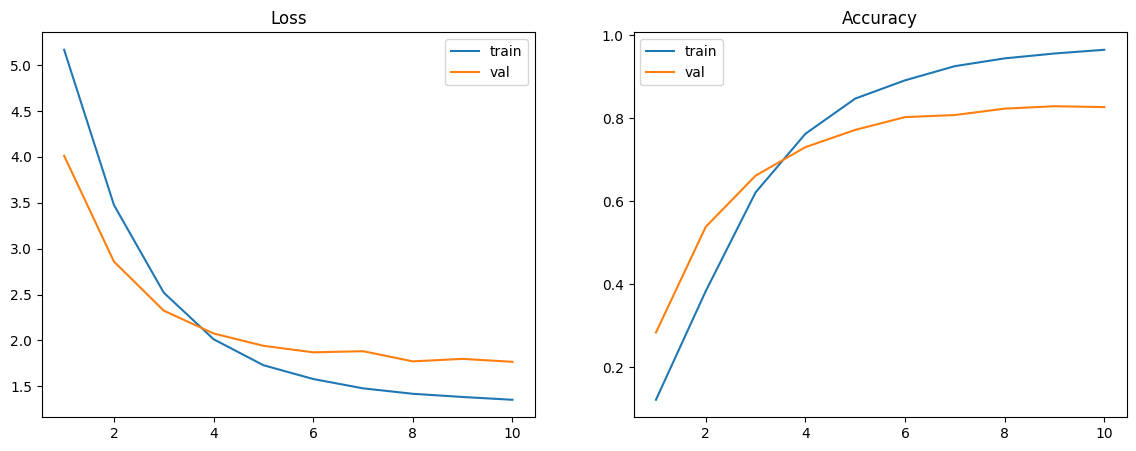

In [24]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["train_acc"], label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

In [25]:
ckpt = torch.load(best_path, map_location=device)

model = build_model(len(ckpt["class_names"])).to(device)
model.load_state_dict(ckpt["model_state_dict"])

val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)

print(f"Val loss: {val_loss:.4f}")
print(f"Val acc : {val_acc:.4f}")
print(f"Val F1  : {val_f1:.4f}")

/tmp/ipykernel_57/2445630436.py:25: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Val loss: 1.7669
Val acc : 0.8269
Val F1  : 0.7942
